# Study of origins of replication

### Datasets:
- Belsky set of origins with annotations for early/late replication timing, origin efficiency, footprint evidence, and nucleosome signals.
- Estimated replication timing.
- Deconvolved chromatin occupancy data.

### Ideas:
- Show the origin timing is linked to estimated replication timing.
- Show that we can analyze footprint, and nucleosome movement timing globally.
- Show a global timecourse representation.
- Show early and late examples.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
fig_origins_updated = FigureOrigins('output/draft4_run/')
fig_origins_updated.setup_data()

In [980]:
fig_origins_updated.setup_processors(force_recompute=True)

Creating directory: output/draft4_run//figure_origins/metrics...Directory exists. Skipping.
***********************
***** Analyzing nucleosomes at two distances: proximal (100bp offset, 500bp window) and distal (600bp offset, 2000bp window) *****
***********************
Starting batch processing of 437 origins...
Detected 257 timepoints from sample origin oridb_5
1/437 00:00:00.801
101/437 00:01:24.618
201/437 00:02:44.579
301/437 00:04:03.295
401/437 00:05:18.755
Completed processing 437 origins!
Saving results to disk...
Results saved to output/draft4_run//figure_origins/metrics/
Loaded 9663 transcripts
  5774 genic transcripts
  3889 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 9663
Loaded expression data: 9663 transcripts, 257 timepoints


In [999]:
#fig_origins_updated.plot_all()

In [1003]:
# from IPython.display import Image, display
# fig_origins_updated.layout_panel()
#display(Image('output/draft4_run/Figures/Debug/Figure6_Origins_debug.png'))

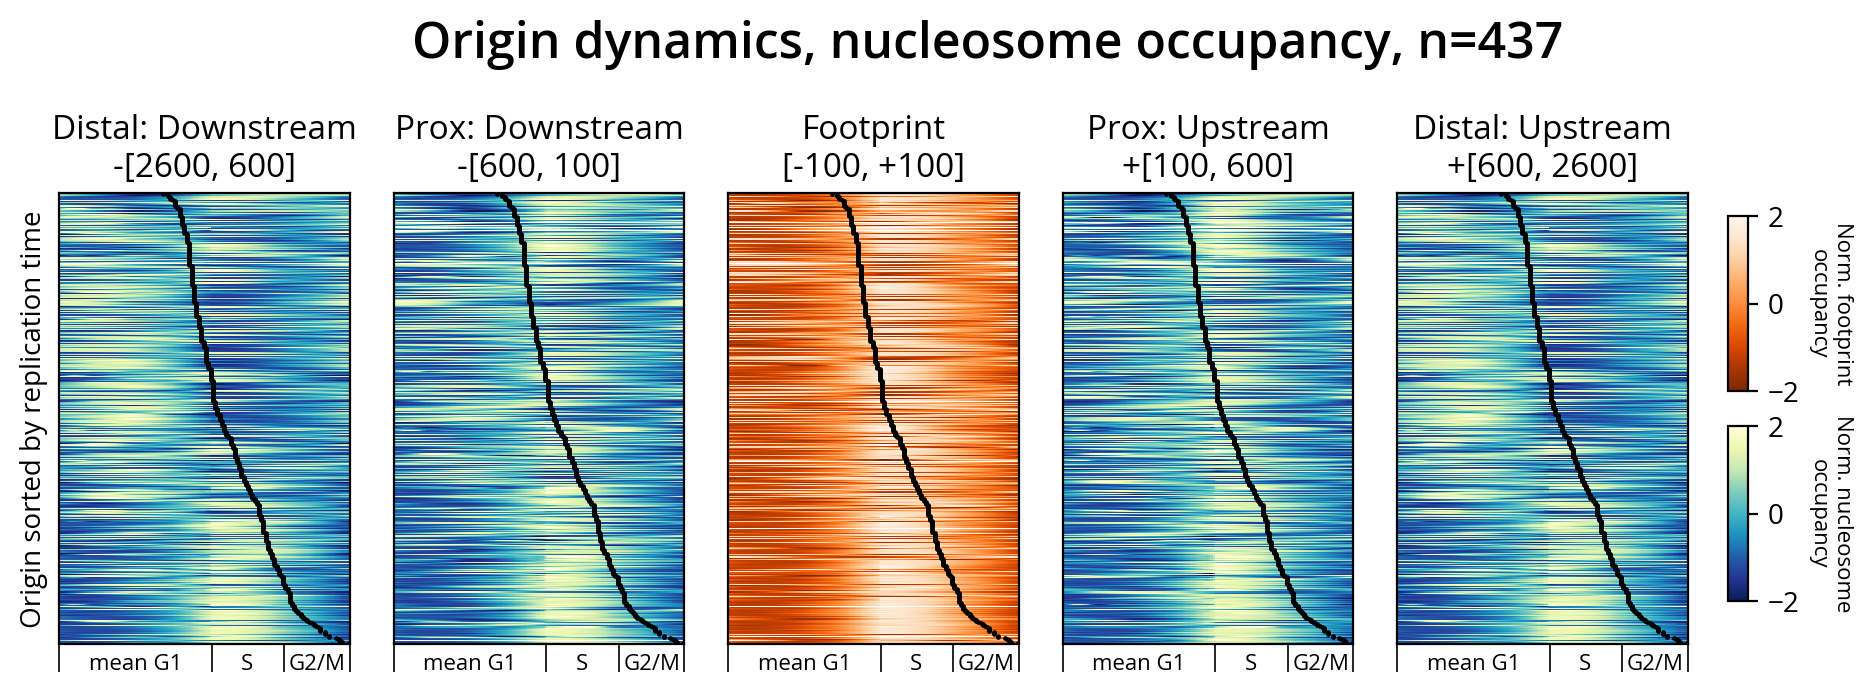

In [1004]:
fig_origins_updated.origin_processor.plot_origin_metrics_heatmaps()

In [1016]:
nucleosome_fork_data = fig_origins_updated.origin_processor.load_origin_fork_region(1, 20000)

Padded data: 5000 -> 6000 positions (front: 1000, back: 0)


In [1025]:
res = fig_origins_updated.origin_processor.process_single_origin_fork_progression(
    1, 20000, "")


Processing origin chr1:20000
Loaded data shape: (257, 7, 6000)
Created 60 windows
First window shape: (257, 7, 100)
Results shapes - Entropy: (257, 60), Occupancy: (257, 60)


ValueError: 'pinks' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_

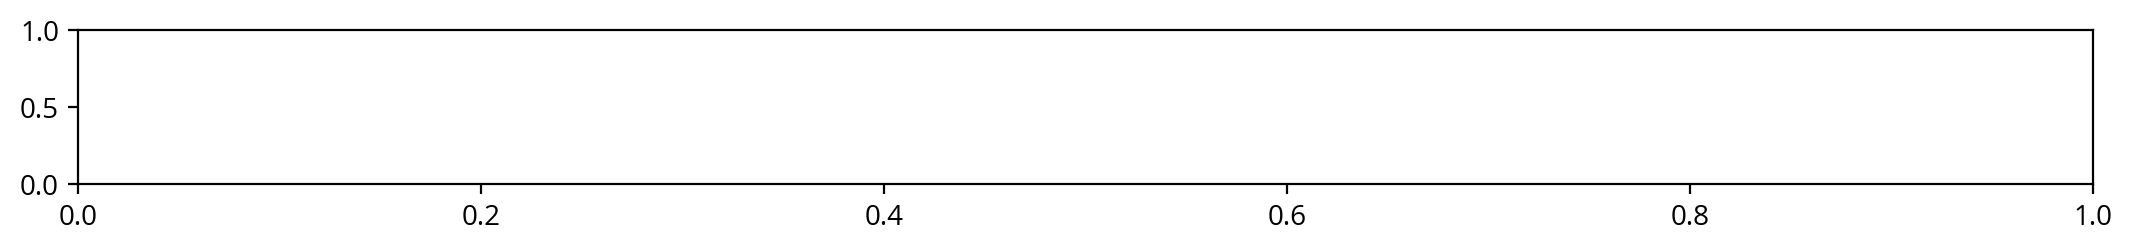

In [1040]:
plt.figure(figsize=(13, 1))
entropy_plot_data = res['entropy'][config1.t_indices()]
normalized_entropy_plot_data = entropy_plot_data / entropy_plot_data.mean(0)[None, :]
plt.imshow(normalized_entropy_plot_data, aspect='auto', interpolation='none',
          cmap='pinks')